In [147]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    RBF,
    Matern,
    RationalQuadratic,
    WhiteKernel,
)
from sklearn.base import clone

from sklearn.metrics import mean_squared_error, r2_score

# SETTINGS
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
KNN_NEIGHBORS = 5

In [148]:
df = pd.read_csv("../data/Data.csv")
print(f"Loaded shape: {df.shape}")

df.sample(10, random_state=RANDOM_STATE)

Loaded shape: (374, 8)


,MOF,Surface area (m2/g),Pore Volume (cm3/g),Catalyst dosage (g/L),Antibiotic dosage (mg/L),Illumination time (min),pH,Degradation (%)
329,MIL-100-PANI,950.00,0.300,0.25,10,15,5.00,8.4
33,MIL-101,180.41,0.320,0.15,50,15,8.20,79.0
15,MIL-101,180.41,0.320,0.20,50,0,4.10,25.0
325,MIL-100-PANI,950.00,0.300,0.25,10,105,3.00,35.8
57,MIL-88A,15.95,0.110,0.25,200,70,3.45,96.8
239,AgI-UiO-66-NH2,425.88,0.273,0.30,10,15,4.30,60.0
76,MIL-88A,15.95,0.110,1.00,200,80,3.45,99.5
119,MIL-88A,15.95,0.110,0.25,200,30,7.00,27.1
332,MIL-100-PANI,950.00,0.300,0.25,10,60,5.00,12.7
126,MIL-88A,15.95,0.110,0.25,200,0,9.00,15.5


In [149]:
buffer_info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
})

buffer_info

,dtype,n_unique,n_missing
MOF,object,10,0
Surface area (m2/g),float64,13,0
Pore Volume (cm3/g),float64,13,0
Catalyst dosage (g/L),float64,12,0
Antibiotic dosage (mg/L),int64,7,0
Illumination time (min),int64,25,0
pH,float64,18,0
Degradation (%),float64,302,0


In [150]:
# Duplicate analysis
n_exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact_duplicates}")

if n_exact_duplicates > 0:
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

Exact duplicate rows: 0


In [151]:
X = df.drop(["Degradation (%)","MOF"], axis=1)
y = df["Degradation (%)"]

feature_names = X.columns.tolist()
n_features = len(feature_names)

In [152]:
def compute_univariate_stats(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Compute descriptive statistics (min, max, mean, median, std, IQR, skew, n_unique)."""
    rows = []
    for col in cols:
        series = pd.to_numeric(df[col], errors="coerce").dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        rows.append({
            "Variable": col,
            "Min": series.min(),
            "Max": series.max(),
            "Mean": series.mean(),
            "Median": series.median(),
            "Std": series.std(),
            "Q1": q1,
            "Q3": q3,
            "IQR": q3 - q1,
            "Skewness": stats.skew(series),
            "N Unique": series.nunique(),
            "N Obs": series.shape[0],
        })

    stats_df = pd.DataFrame(rows).set_index("Variable").round(3)
    return stats_df

# Execute Phase
univariate_stats = compute_univariate_stats(df, X)
print("UNIVARIATE DESCRIPTIVE STATISTICS")
display(univariate_stats)

UNIVARIATE DESCRIPTIVE STATISTICS


,Min,Max,Mean,Median,Std,Q1,Q3,IQR,Skewness,N Unique,N Obs
Variable,,,,,,,,,,,
Surface area (m2/g),15.95,1548.30,374.222,252.59,351.250,180.41,425.88,245.47,1.177,13,374
Pore Volume (cm3/g),0.11,0.86,0.353,0.30,0.247,0.20,0.32,0.12,1.190,13,374
Catalyst dosage (g/L),0.05,2.00,0.412,0.30,0.409,0.25,0.50,0.25,2.656,12,374
Antibiotic dosage (mg/L),10.00,200.00,66.588,40.00,74.552,10.00,50.00,40.00,1.142,7,374
Illumination time (min),0.00,360.00,43.810,30.00,46.320,10.00,60.00,50.00,2.260,25,374
pH,1.00,12.20,5.871,5.50,2.489,4.10,8.00,3.90,0.078,18,374


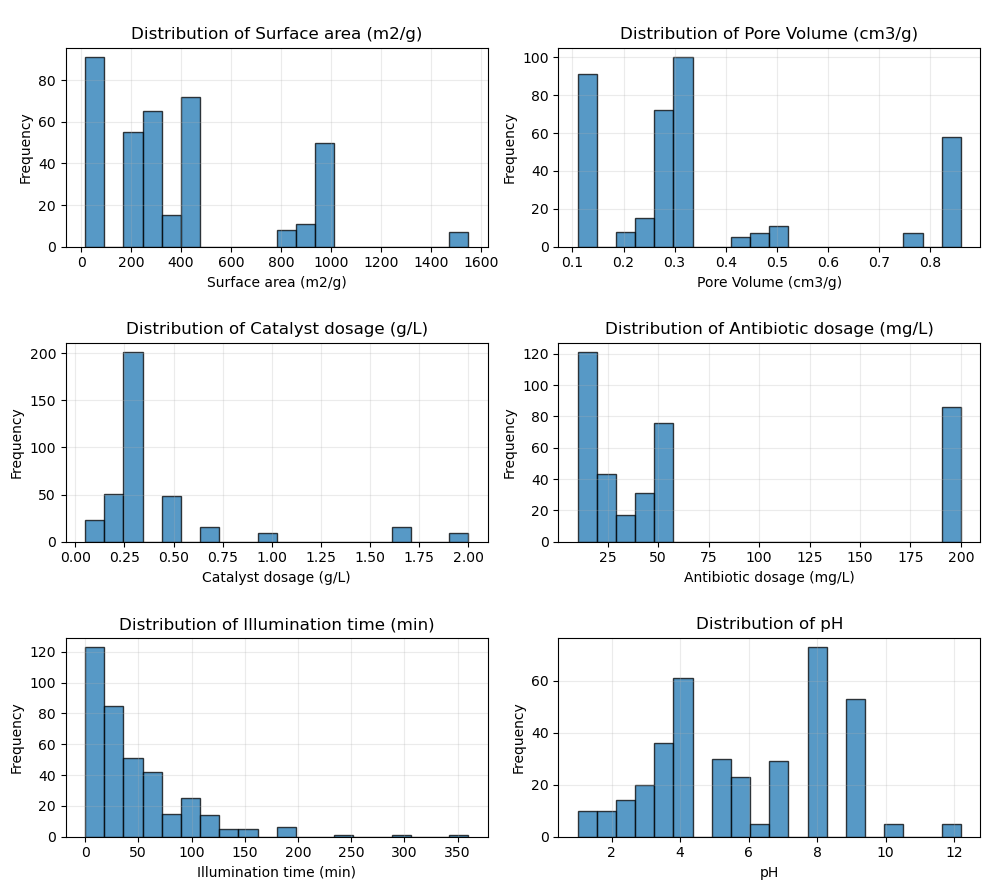

In [153]:
# Plot the distribution of each input feature in a two-column layout

n_cols = 2
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    nrows=n_rows,
    ncols=n_cols,
    figsize=(10, 3 * n_rows)
)

# Flatten the axes array to make iteration easier
axes = np.atleast_1d(axes).ravel()

for ax, feature in zip(axes, feature_names):
    values = X[feature]

    # Plot the feature histogram
    ax.hist(
        values,
        bins=20,
        edgecolor="black",
        alpha=0.75
    )

    ax.set_title(f"\nDistribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.25)

# Hide any unused subplot if the number of features is odd
for ax in axes[n_features:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


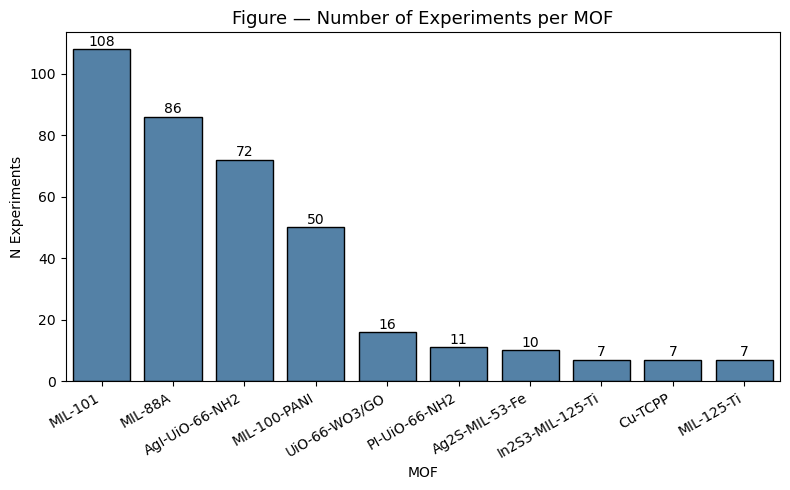

In [154]:
# Analyze MOFs (Categorical)
def plot_categorical_distribution(
    df: pd.DataFrame,
    col: str,
    order: list[str] | None = None,
    annotate: bool = True,
) -> None:
    """Bar plot of counts per category, ordered by frequency."""
    counts = df[col].value_counts()
    if order is None:
        order = counts.index.tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        x=counts.loc[order].index,
        y=counts.loc[order].values,
        order=order,
        color="steelblue",
        edgecolor="black",
        ax=ax,
    )

    if annotate:
        for i, val in enumerate(counts.loc[order].values):
            ax.text(i, val + counts.max() * 0.01, str(val), ha="center", fontsize=10)

    ax.set_title(f"Figure — Number of Experiments per {col}", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("N Experiments")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Execute
plot_categorical_distribution(df, "MOF")

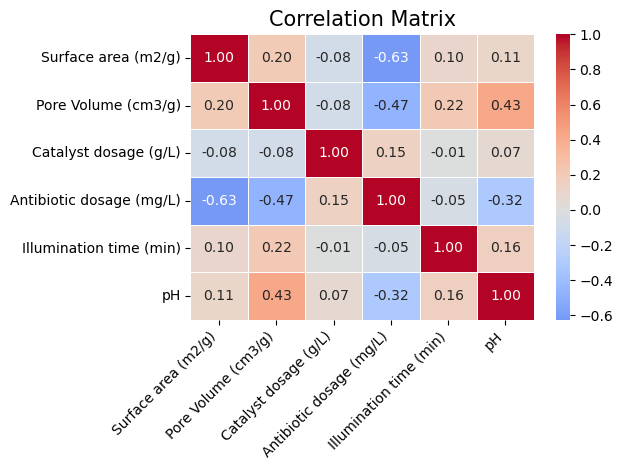

In [155]:
# CORRELATION MATRIX
corr_matrix = X.corr()

plt.figure()

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [156]:
# VIF CHECK

X_vif = X

# Add intercept
X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

# Remove intercept from results
vif_data = vif_data[vif_data["Variable"] != "const"]

# Sort highest to lowest
vif_data = (
    vif_data
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

display(vif_data.round(3))

,Variable,VIF
0,Antibiotic dosage (mg/L),2.189
1,Surface area (m2/g),1.716
2,Pore Volume (cm3/g),1.517
3,pH,1.290
4,Illumination time (min),1.082
5,Catalyst dosage (g/L),1.041


In [157]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

In [158]:
# GPR kernels

SIGNAL_BOUNDS = (1e-4, 1e4)
LENGTH_SCALE_BOUNDS = (1e-3, 1e3)
NOISE_BOUNDS = (1e-6, 1e1)

MATERN_NU = 1.5

kernels = {
    "GPR Matern": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=SIGNAL_BOUNDS,
        )
        * Matern(
            length_scale=1.0,
            length_scale_bounds=LENGTH_SCALE_BOUNDS,
            nu=MATERN_NU,
        )
        + WhiteKernel(
            noise_level=0.02,
            noise_level_bounds=NOISE_BOUNDS,
        )
    ),

    "GPR Exp": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=SIGNAL_BOUNDS,
        )
        * Matern(
            length_scale=1.0,
            length_scale_bounds=LENGTH_SCALE_BOUNDS,
            nu=0.5,
        )
        + WhiteKernel(
            noise_level=0.02,
            noise_level_bounds=NOISE_BOUNDS,
        )
    ),

    "GPR SExp": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=SIGNAL_BOUNDS,
        )
        * RBF(
            length_scale=1.0,
            length_scale_bounds=LENGTH_SCALE_BOUNDS,
        )
        + WhiteKernel(
            noise_level=0.02,
            noise_level_bounds=NOISE_BOUNDS,
        )
    ),

    "GPR Rational Quadratic": (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=SIGNAL_BOUNDS,
        )
        * RationalQuadratic(
            length_scale=1.0,
            alpha=1.0,
            length_scale_bounds=LENGTH_SCALE_BOUNDS,
            alpha_bounds=(1e-3, 1e3),
        )
        + WhiteKernel(
            noise_level=0.02,
            noise_level_bounds=NOISE_BOUNDS,
        )
    ),
}


In [159]:
# Build the GPR pipeline.

N_RESTARTS_OPTIMIZER = 20

def make_gpr_model(
    kernel,
    *,
    random_state=RANDOM_STATE,
    n_restarts_optimizer=N_RESTARTS_OPTIMIZER,
):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "gpr",
                GaussianProcessRegressor(
                    kernel=clone(kernel),

                    # Observation noise is represented by WhiteKernel.
                    # A tiny alpha is retained only as numerical jitter.
                    alpha=1e-10,

                    # Centering the target is compatible with the paper's
                    # zero-mean GP formulation and improves numerical stability.
                    normalize_y=True,

                    n_restarts_optimizer=n_restarts_optimizer,
                    random_state=random_state,
                ),
            ),
        ]
    )


In [160]:
# Performance metrics used for model evaluation

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    residuals = y_true - y_pred

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    denominator = np.where(
        np.abs(y_true) < 1e-12,
        np.nan,
        np.abs(y_true),
    )
    mre = np.nanmean(np.abs(y_pred - y_true) / denominator) * 100.0

    std = np.std(residuals, ddof=0)

    return {
        "R²": r2,
        "MRE (%)": mre,
        "MSE": mse,
        "RMSE": rmse,
        "STD": std,
    }


In [161]:
# Fit the four GPR models and evaluate train, test, and total data.

fitted_models = {}
results = []
optimized_kernels = {}

for model_name, kernel in kernels.items():
    model = make_gpr_model(kernel)

    # Fit only on the training subset.
    model.fit(X_train, y_train)
    fitted_models[model_name] = model

    # Generate predictions for the three reporting subsets.
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_total_pred = model.predict(X)

    train_metrics = regression_metrics(y_train, y_train_pred)
    test_metrics = regression_metrics(y_test, y_test_pred)
    total_metrics = regression_metrics(y, y_total_pred)

    for dataset_name, model_metrics in [
        ("Train", train_metrics),
        ("Test", test_metrics),
        ("Total", total_metrics),
    ]:
        results.append(
            {
                "Model": model_name,
                "Dataset": dataset_name,
                **model_metrics,
            }
        )

    optimized_kernels[model_name] = model.named_steps["gpr"].kernel_

print("Optimized kernels")
for model_name, optimized_kernel in optimized_kernels.items():
    print(f"{model_name}: {optimized_kernel}")


Optimized kernels
GPR Matern: 2.12**2 * Matern(length_scale=2.14, nu=1.5) + WhiteKernel(noise_level=0.027)
GPR Exp: 2.9**2 * Matern(length_scale=23, nu=0.5) + WhiteKernel(noise_level=0.0181)
GPR SExp: 1.61**2 * RBF(length_scale=0.907) + WhiteKernel(noise_level=0.0363)
GPR Rational Quadratic: 2.69**2 * RationalQuadratic(alpha=0.201, length_scale=1.72) + WhiteKernel(noise_level=0.031)


In [162]:
# Results table
gpr_results = pd.DataFrame(results)

metric_columns = ["R²", "MRE (%)", "MSE", "RMSE", "STD"]
for col in metric_columns:
    gpr_results[col] = gpr_results[col].astype(float)

table_1_df = (
    gpr_results
    .set_index(["Model", "Dataset"])
    .round(
        {
            "R²": 3,
            "MRE (%)": 2,
            "MSE": 2,
            "RMSE": 2,
            "STD": 2,
        }
    )
)

print("Statistical parameters of the GPR models")
display(table_1_df)

Statistical parameters of the GPR models


R²  MRE (%)    MSE  RMSE   STD
Model                  Dataset                                   
GPR Matern             Train    0.987     8.10  11.09  3.33  3.33
                       Test     0.902    23.18  78.03  8.83  8.82
                       Total    0.971    11.13  24.51  4.95  4.95
GPR Exp                Train    0.997     4.31   2.92  1.71  1.71
                       Test     0.879    49.09  96.08  9.80  9.74
                       Total    0.975    13.29  21.60  4.65  4.64
GPR SExp               Train    0.978    12.15  18.94  4.35  4.35
                       Test     0.914    24.19  68.06  8.25  8.24
                       Total    0.966    14.57  28.79  5.37  5.37
GPR Rational Quadratic Train    0.983     9.39  14.58  3.82  3.82
                       Test     0.907    23.88  74.18  8.61  8.60
                       Total    0.969    12.30  26.53  5.15  5.15

In [163]:
# Quantify sensitivity to the unspecified random train/test split
split_scores = []

# Use a single optimizer start here to keep the diagnostic lightweight
for seed in range(30):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed,
        shuffle=True,
    )

    diagnostic_model = make_gpr_model(
        kernels["GPR Matern"],
        random_state=seed,
        n_restarts_optimizer=0,
    )
    diagnostic_model.fit(X_tr, y_tr)

    y_te_pred = diagnostic_model.predict(X_te)
    split_scores.append(
        {
            "Seed": seed,
            **regression_metrics(y_te, y_te_pred),
        }
    )

split_sensitivity_df = pd.DataFrame(split_scores)

print("Matern test performance across 30 valid random 80/20 splits")
display(
    split_sensitivity_df[
        ["R²", "MRE (%)", "MSE", "RMSE"]
    ]
    .agg(["min", "median", "max"])
    .round(3)
)


Matern test performance across 30 valid random 80/20 splits


,R²,MRE (%),MSE,RMSE
min,0.858,8.526,28.289,5.319
median,0.916,32.994,62.385,7.898
max,0.971,67.661,109.862,10.481


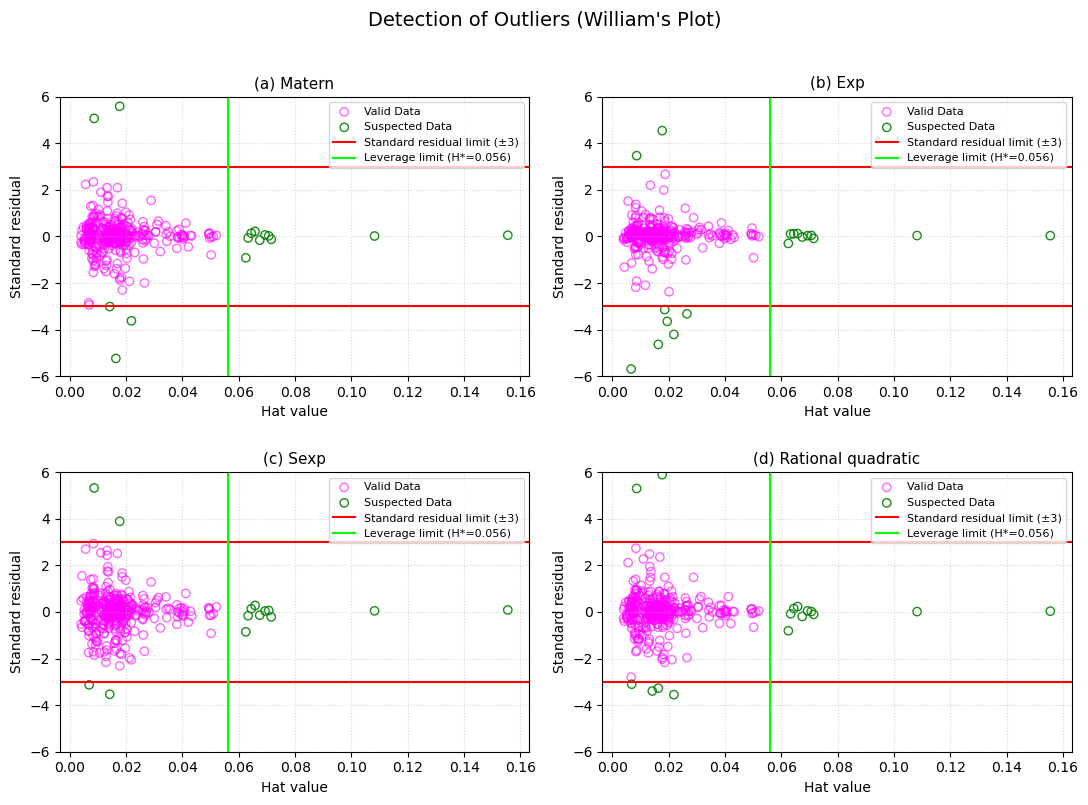

In [164]:
# LEVERAGE OUTLIER DETECTION: WILLIAM'S PLOT
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

# Hat matrix Leverage threshold
n_samples, n_params = X.shape[0], X.shape[1]
h_star = 3.0 * (n_params + 1) / n_samples

X_mat = np.column_stack([np.ones(n_samples), StandardScaler().fit_transform(X)])
H = X_mat @ np.linalg.pinv(X_mat.T @ X_mat) @ X_mat.T
hat_values = np.diag(H)

for idx, (model_name, model_pipe) in enumerate(fitted_models.items()):
    ax = axes[idx]
    y_pred_all = model_pipe.predict(X)
    residuals = y.values - y_pred_all
    std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

    # Classify valid vs suspected
    is_outlier = (np.abs(std_residuals) > 3) | (hat_values > h_star)
    
    ax.scatter(hat_values[~is_outlier], std_residuals[~is_outlier], 
               facecolors="none", edgecolors="magenta", label="Valid Data", alpha=0.6)
    ax.scatter(hat_values[is_outlier], std_residuals[is_outlier], 
               facecolors="none", edgecolors="green", label="Suspected Data", alpha=0.9)

    ax.axhline(3, color="red", linestyle="-", lw=1.5, label="Standard residual limit (±3)")
    ax.axhline(-3, color="red", linestyle="-", lw=1.5)
    ax.axvline(h_star, color="lime", linestyle="-", lw=1.5, label=f"Leverage limit (H*={h_star:.3f})")

    ax.set_title(f"\n({chr(97 + idx)}) {model_name.replace('GPR ', '').capitalize()}", fontsize=11)
    ax.set_xlabel("Hat value")
    ax.set_ylabel("Standard residual")
    ax.set_ylim(-6, 6)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Detection of Outliers (William's Plot)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

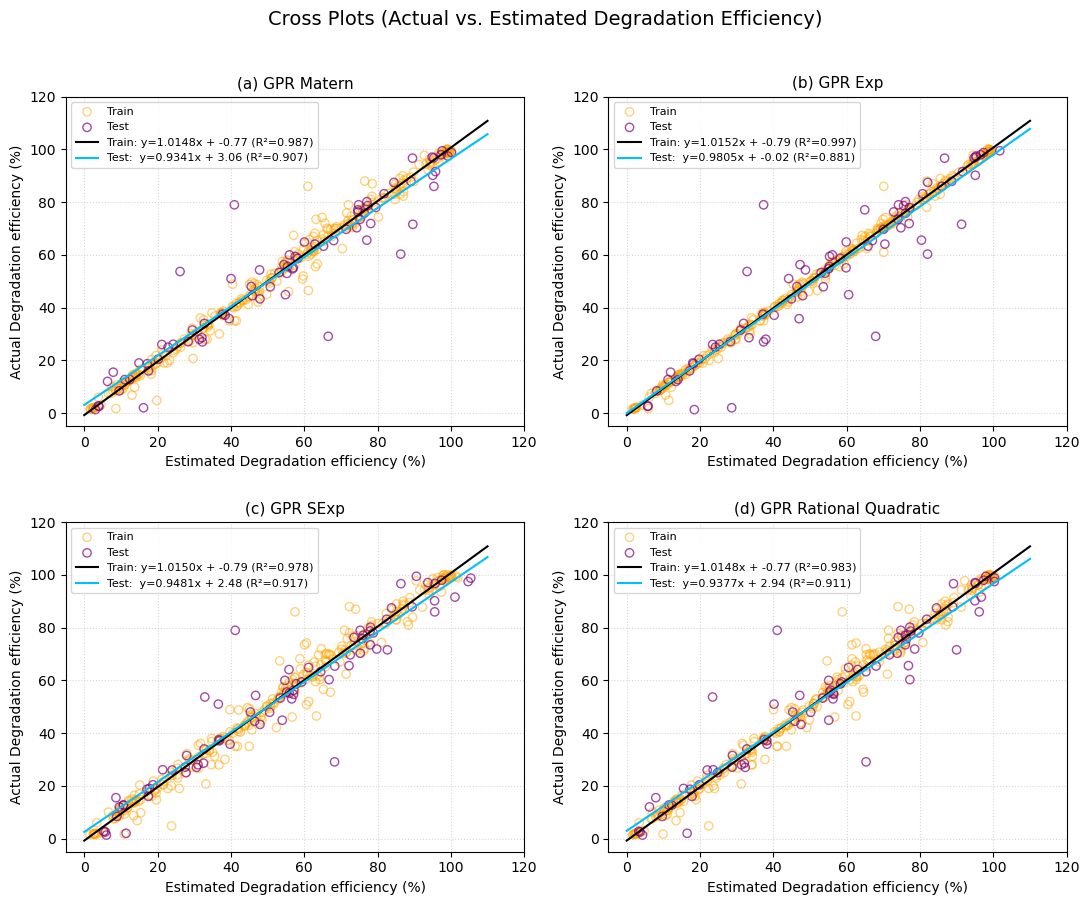

In [165]:
# CROSS-PLOTS & LINEAR REGRESSION FITS
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for idx, (model_name, model_pipe) in enumerate(fitted_models.items()):
    ax = axes[idx]
    
    # Train fit line
    y_tr_pred = model_pipe.predict(X_train)
    slope_tr, intercept_tr, r_val_tr, _, _ = stats.linregress(y_tr_pred, y_train)
    
    # Test fit line
    y_te_pred = model_pipe.predict(X_test)
    slope_te, intercept_te, r_val_te, _, _ = stats.linregress(y_te_pred, y_test)

    ax.scatter(y_tr_pred, y_train, facecolors="none", edgecolors="orange", alpha=0.5, label="Train")
    ax.scatter(y_te_pred, y_test, facecolors="none", edgecolors="purple", alpha=0.7, label="Test")

    x_domain = np.linspace(0, 110, 100)
    ax.plot(x_domain, slope_tr * x_domain + intercept_tr, color="black", lw=1.5, 
            label=f"Train: y={slope_tr:.4f}x + {intercept_tr:.2f} (R²={r_val_tr**2:.3f})")
    ax.plot(x_domain, slope_te * x_domain + intercept_te, color="deepskyblue", lw=1.5, 
            label=f"Test:  y={slope_te:.4f}x + {intercept_te:.2f} (R²={r_val_te**2:.3f})")

    ax.set_title(f"\n({chr(97 + idx)}) {model_name}", fontsize=11)
    ax.set_xlabel("Estimated Degradation efficiency (%)")
    ax.set_ylabel("Actual Degradation efficiency (%)")
    ax.set_xlim(-5, 120)
    ax.set_ylim(-5, 120)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Cross Plots (Actual vs. Estimated Degradation Efficiency)", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

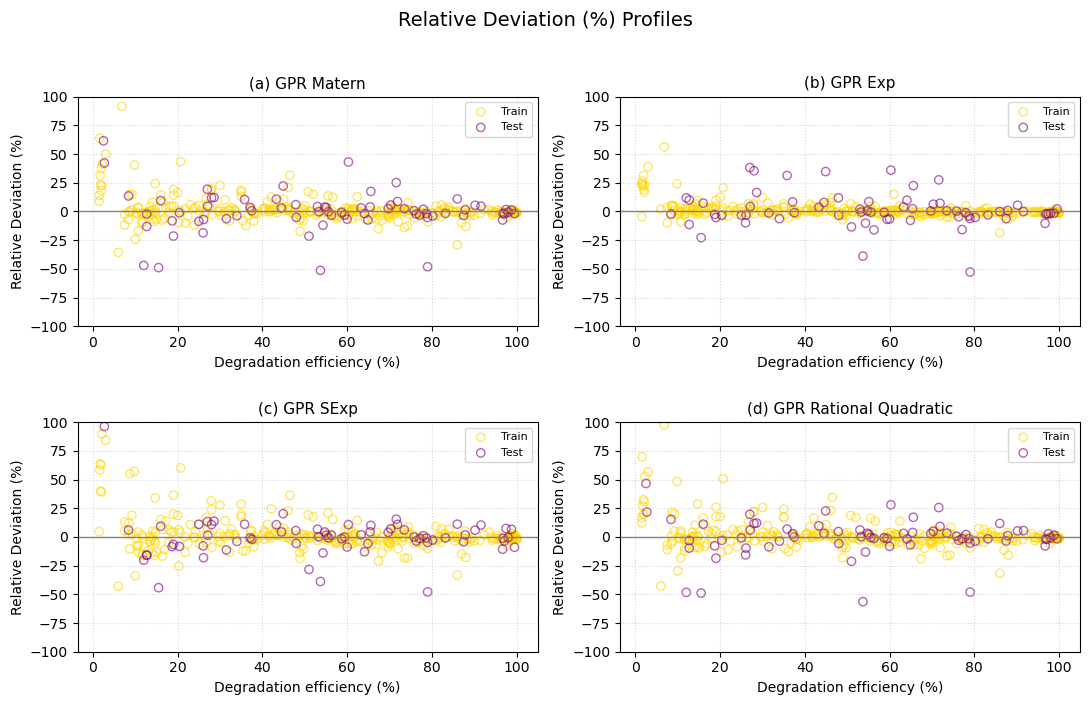

In [166]:
# RELATIVE DEVIATION PROFILES
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

for idx, (model_name, model_pipe) in enumerate(fitted_models.items()):
    ax = axes[idx]
    
    y_tr_pred = model_pipe.predict(X_train)
    y_te_pred = model_pipe.predict(X_test)
    
    dev_tr = ((y_tr_pred - y_train.values) / np.where(y_train.values == 0, 1e-6, y_train.values)) * 100
    dev_te = ((y_te_pred - y_test.values) / np.where(y_test.values == 0, 1e-6, y_test.values)) * 100

    ax.scatter(y_train, dev_tr, facecolors="none", edgecolors="gold", alpha=0.6, label="Train")
    ax.scatter(y_test, dev_te, facecolors="none", edgecolors="purple", alpha=0.6, label="Test")
    ax.axhline(0, color="gray", lw=1)

    ax.set_title(f"\n({chr(97 + idx)}) {model_name}", fontsize=11)
    ax.set_xlabel("Degradation efficiency (%)")
    ax.set_ylabel("Relative Deviation (%)")
    ax.set_ylim(-100, 100)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

fig.suptitle("Relative Deviation (%) Profiles", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()